In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("/content/drive/MyDrive/Data Science/Dataset/Statewide Solar Projects.csv",low_memory=False)

#Eda and Preprocessing


In [5]:
df.head()

,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,12/31/2023,SDG-66301,12/29/2023,Con Ed,Richmond Hill,Queens,11418.0,CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1
1,12/31/2023,SDG-66299,12/29/2023,Con Ed,Bronx,Bronx,10473.0,CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,NaN,1
2,12/31/2023,SDG-66288,12/29/2023,Con Ed,Brooklyn,Kings,11225.0,CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585,NaN,1
3,12/31/2023,SDG-66284,12/29/2023,Con Ed,Brooklyn,Kings,11236.0,CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,NaN,1
4,12/31/2023,SDG-66277,12/28/2023,Con Ed,Springfield Gardens,Queens,11413.0,CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1


shows the first 5 rows of the dataset for a quick preview.

In [6]:
df.tail()

,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
218110,12/31/2023,49,12/19/2002,RGE,Ontario,Wayne,14519.0,Sodus,0205LS0237-1589 RTE 104,0205LS0237,NaN,NM,2.81,2.4,3296,NaN,1
218111,12/31/2023,48,9/24/2002,RGE,Friendship,Allegany,14739.0,Fillmore,8333GV7702-Friendship Nile RD,8333GV7702,NaN,NM,2.93,2.5,3433,NaN,1
218112,12/31/2023,NaN,7/1/2018,PSEGLI,NaN,Suffolk,11786.0,NaN,NaN,NaN,NaN,FIT,34362.00,24900.0,40335490,NaN,1
218113,12/31/2023,NaN,3/3/2018,PSEGLI,NaN,Suffolk,11933.0,NaN,NaN,NaN,NaN,FIT,27600.00,20000.0,32397984,NaN,1
218114,12/31/2023,NaN,11/1/2011,PSEGLI,NaN,Suffolk,11973.0,NaN,NaN,NaN,NaN,FIT,43470.00,31500.0,51026825,NaN,1


shows the last 5 rows of the dataset.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218115 entries, 0 to 218114
Data columns (total 17 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Data Through Date                            218115 non-null  object 
 1   Project ID                                   218112 non-null  object 
 2   Interconnection Date                         218115 non-null  object 
 3   Utility                                      218115 non-null  object 
 4   City/Town                                    218057 non-null  object 
 5   County                                       218115 non-null  object 
 6   Zip                                          218019 non-null  float64
 7   Division                                     132881 non-null  object 
 8   Substation                                   138171 non-null  object 
 9   Circuit ID                                   218085 non-nul

provides a summary of the dataset, including column names, data types, and non-null values.

In [8]:
df.dtypes

,0
Data Through Date,object
Project ID,object
Interconnection Date,object
Utility,object
City/Town,object
County,object
Zip,float64
Division,object
Substation,object
Circuit ID,object


shows the data type of each column in the dataset.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Zip,218019.0,11751.734473,962.129108,10001.00,11220.00,11717.00,12018.00,14905.0
Estimated PV System Size (kWdc),218115.0,24.507977,291.525394,0.01,5.27,7.13,10.24,43470.0
PV System Size (kWac),218115.0,19.065451,211.419642,0.01,4.50,6.09,8.75,31500.0
Estimated Annual PV Energy Production (kWh),218115.0,28768.278592,342204.175266,14.00,6180.00,8364.00,12017.00,51026825.0
Energy Storage System Size (kWac),4091.0,32.174727,296.161116,0.35,5.00,7.60,10.00,5000.0
Number of Projects,218115.0,1.000000,0.000000,1.00,1.00,1.00,1.00,1.0


shows statistical summary (mean, std, min, max, etc.) of numerical columns in a transposed format.

In [10]:
df.isna().sum()

,0
Data Through Date,0
Project ID,3
Interconnection Date,0
Utility,0
City/Town,58
County,0
Zip,96
Division,85234
Substation,79944
Circuit ID,30


shows the total number of missing values in each column.

In [11]:
df = df.drop(columns=[
"Division",
"Substation",
"Developer",
"Metering Method",
"Project ID",
"Circuit ID",
"Data Through Date",
"Energy Storage System Size (kWac)"
], errors="ignore")

removes specified unnecessary columns from the dataset to simplify analysis, ignoring any columns that may not exist.

In [12]:
df['Efficiency'] = df['Estimated Annual PV Energy Production (kWh)'] / df['Estimated PV System Size (kWdc)']

This creates an Efficiency feature to measure how effectively the solar system converts size into energy output, improving clustering insights.

In [13]:
df['AC_DC_Ratio'] = df['PV System Size (kWac)'] / df['Estimated PV System Size (kWdc)']

This creates an AC/DC Ratio feature to capture system design efficiency and improve clustering differentiation.

In [14]:
df = df.dropna(subset=["City/Town","Zip"])

This removes rows with missing City/Town or Zip values to ensure data completeness for analysis.

In [15]:
df.duplicated().sum()

np.int64(3516)

returns the number of duplicate rows in the dataset.

In [16]:
df = df.drop_duplicates()

This removes duplicate rows from the dataset to ensure data uniqueness and accuracy.

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
features = [
    'Estimated PV System Size (kWdc)',
    'PV System Size (kWac)',
    'Estimated Annual PV Energy Production (kWh)',
    'Efficiency',
    'AC_DC_Ratio'
]

X = df[features]

This selects key numerical features and creates a subset X for clustering analysis.

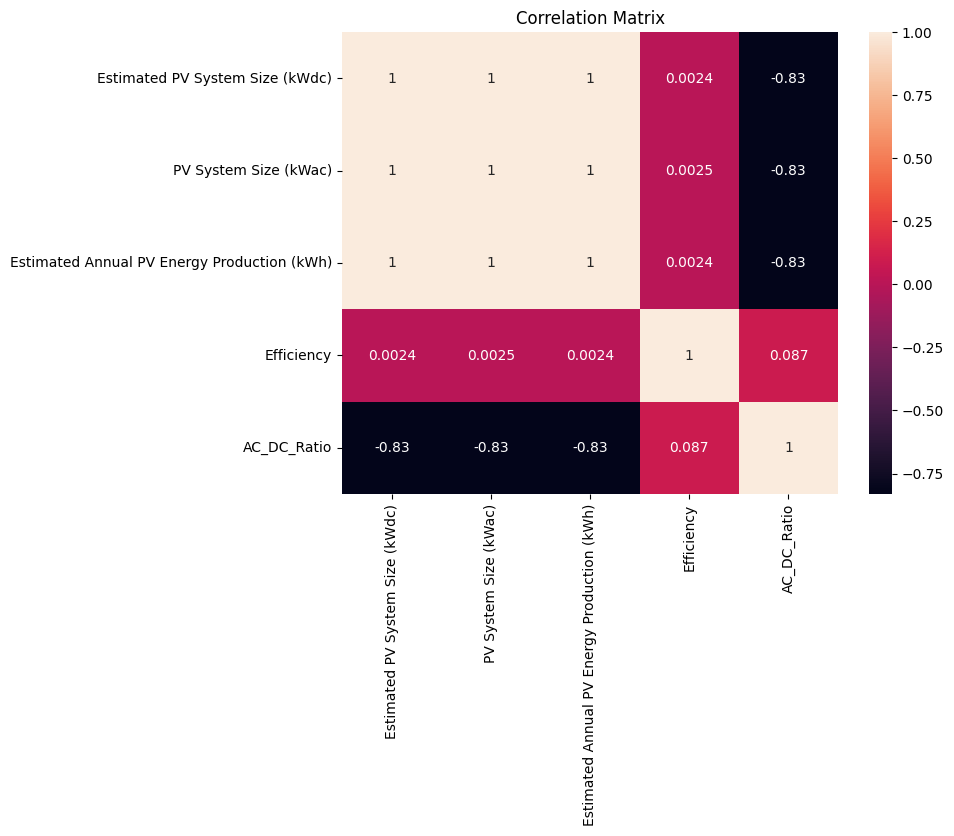

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

This visualizes the correlation between features using a heatmap to identify relationships and dependencies. Clustering is distance-based → only numeric data

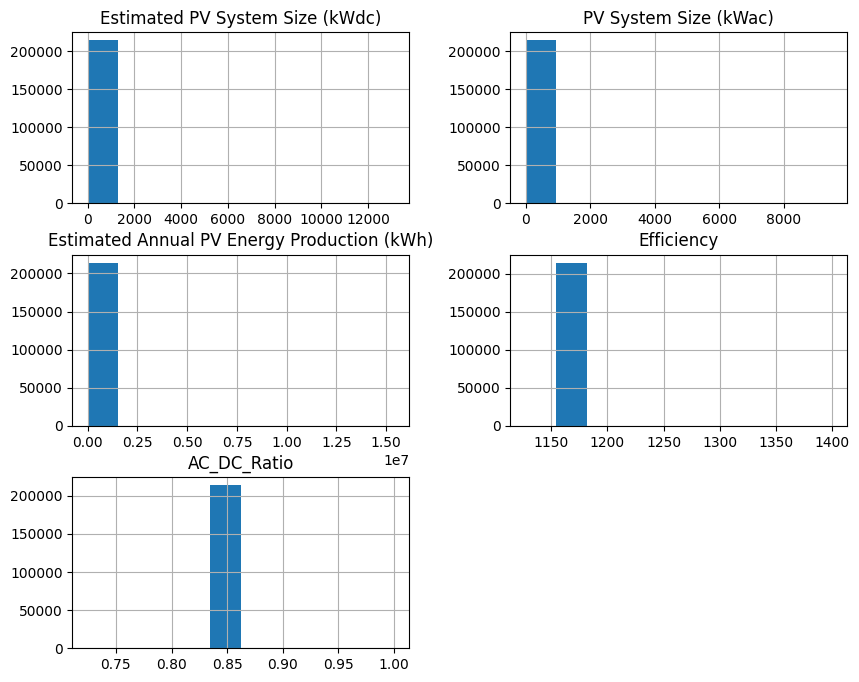

In [20]:
X.hist(figsize=(10,8))
plt.show()



*   The features PV System Size (kWdc) and Energy Production (kWh) are highly right-skewed
→ Most solar projects are small-sized, with a few very large installations
Efficiency values are relatively concentrated, indicating similar performance across many systems
Presence of extreme values (outliers) suggests large commercial/industrial projects
*   Efficiency values are relatively concentrated, indicating similar performance across many systems.


*   Presence of extreme values (outliers) suggests large commercial/industrial projects






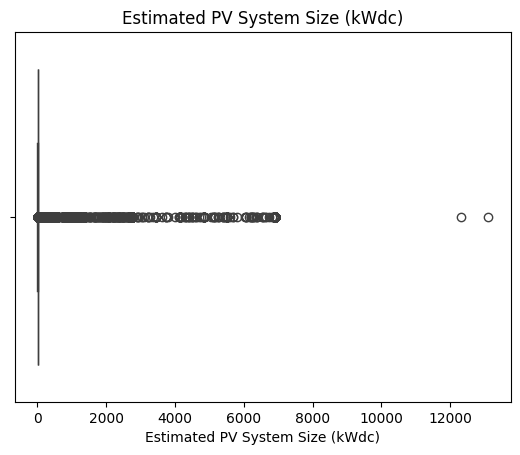

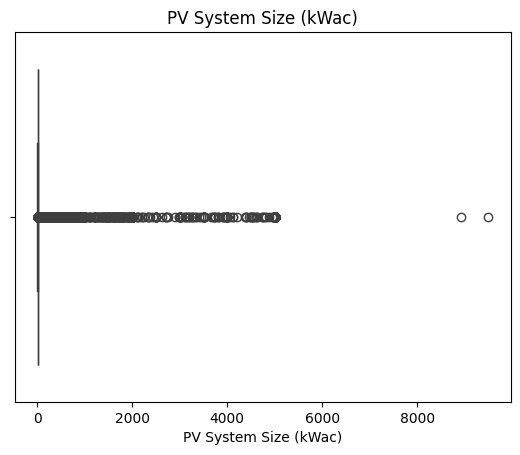

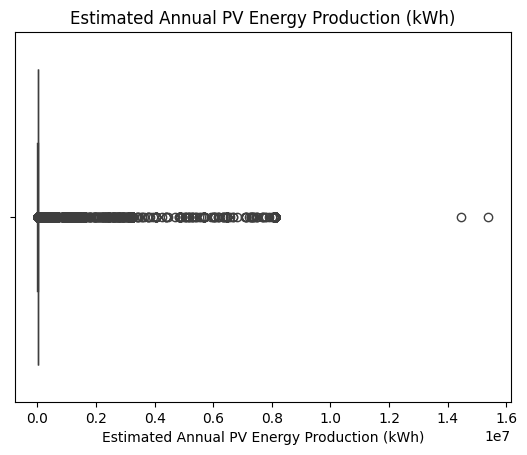

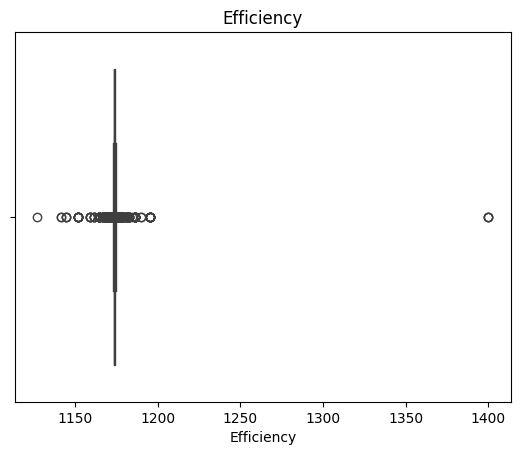

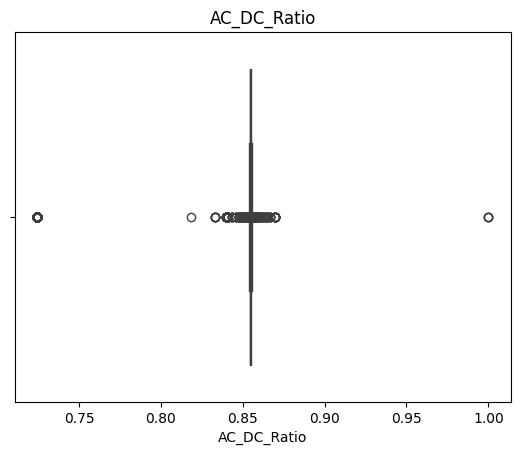

In [21]:
for col in X.columns:
    sns.boxplot(x=X[col])
    plt.title(col)
    plt.show()

Boxplots reveal significant outliers in system size and energy production, indicating a few large-scale projects, while most installations remain small to medium-sized with relatively consistent efficiency.

In [22]:
X = X.clip(lower=X.quantile(0.01),
           upper=X.quantile(0.99),
           axis=1)

This clips extreme values at the 1st and 99th percentiles to reduce the impact of outliers and stabilize clustering.

In [23]:
X = X.fillna(X.mean())

This fills missing values with the mean of each column to ensure complete data for modeling.

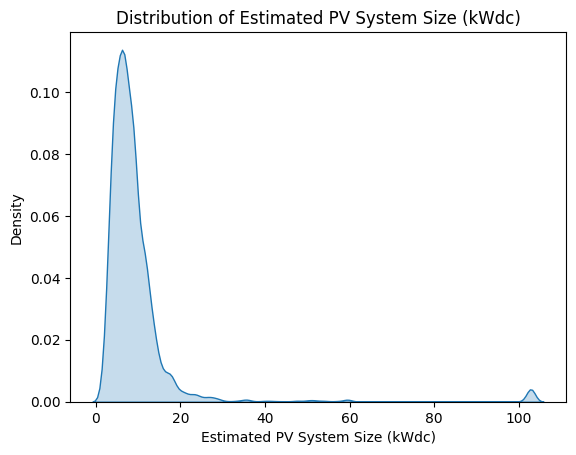

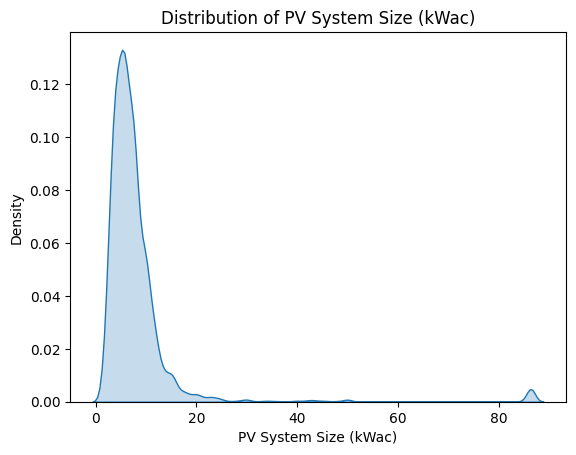

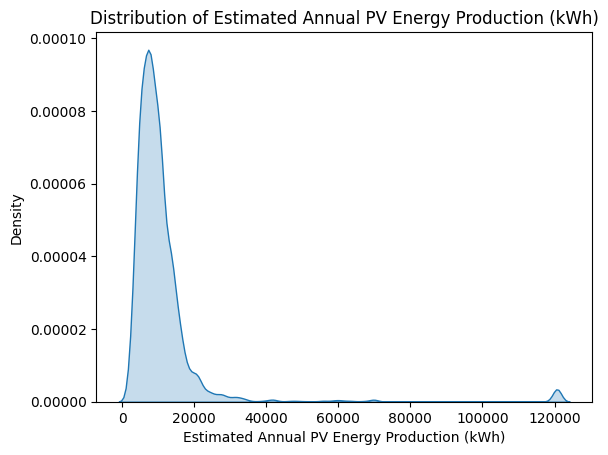

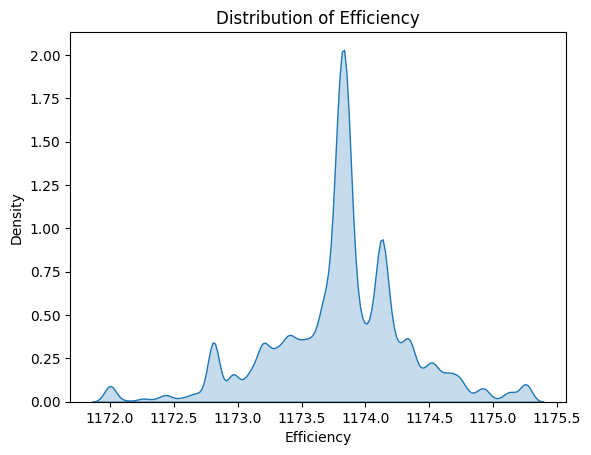

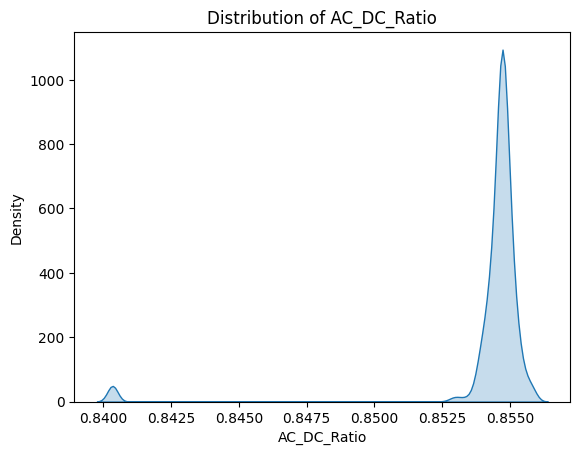

In [24]:
for col in features:
    sns.kdeplot(X[col], fill=True)
    plt.title(f"Distribution of {col}")
    plt.show()

This plots smooth density curves for each feature to better understand their distribution and skewness.

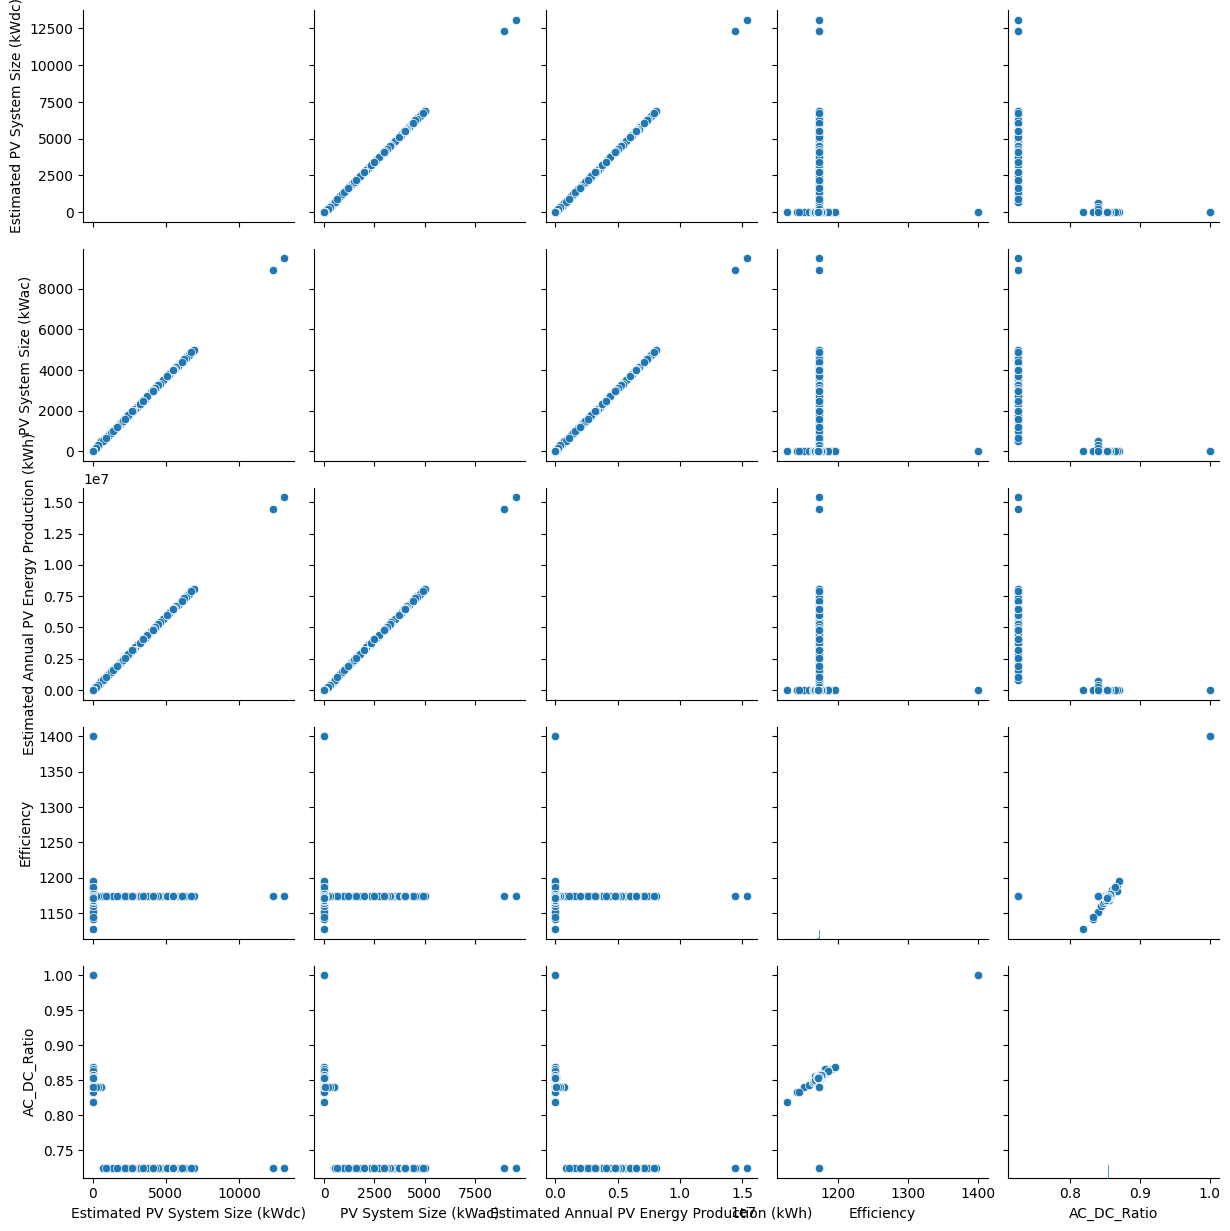

In [25]:
sns.pairplot(df[features])
plt.show()

creates pairwise scatter plots to visualize relationships and patterns between all selected features.

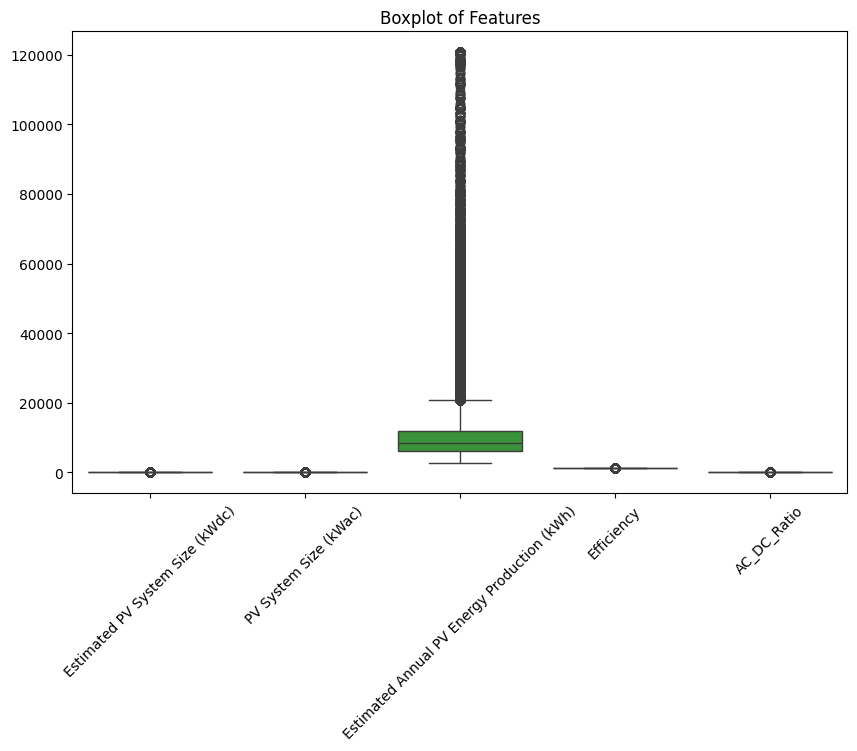

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(data=X)
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

This boxplot compares all features, showing that most values are concentrated at lower ranges with some extreme outliers present.

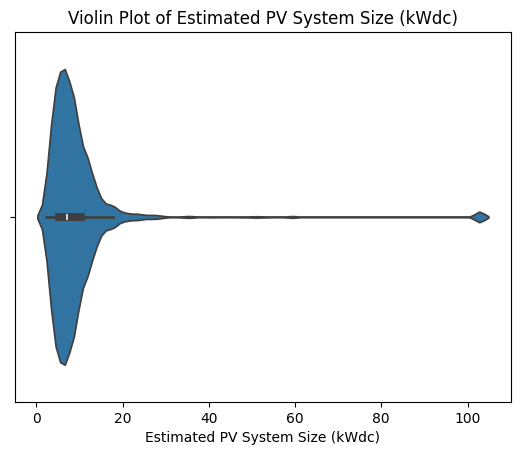

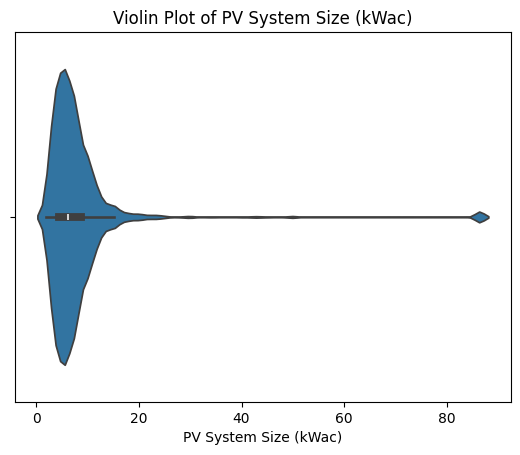

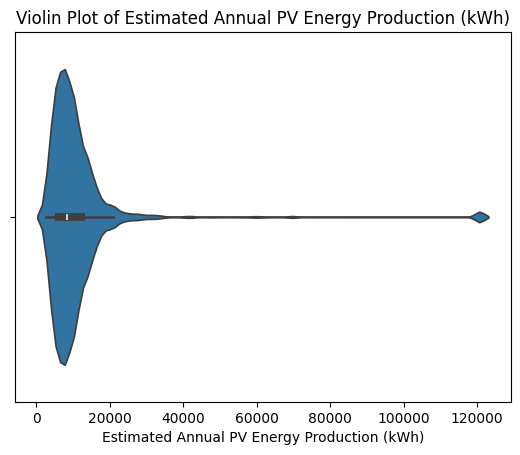

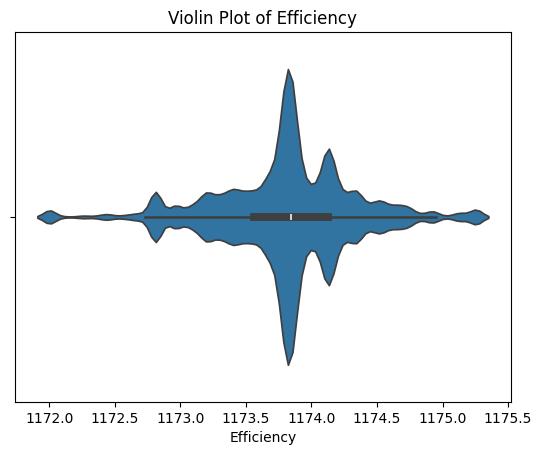

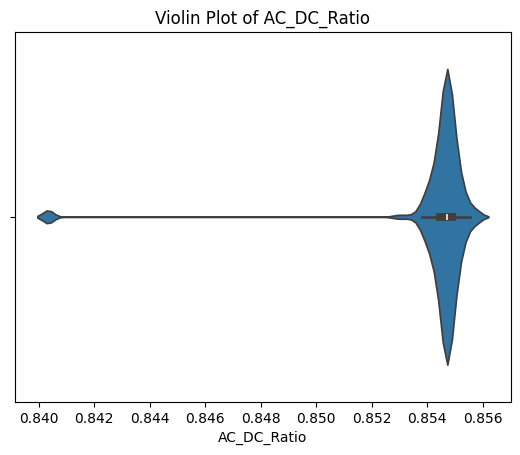

In [27]:
for col in features:
    sns.violinplot(x=X[col])
    plt.title(f"Violin Plot of {col}")
    plt.show()

visualizes the distribution and density of each feature, highlighting skewness and variation in the data.

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

standardizes the features to have mean 0 and variance 1, ensuring fair distance-based clustering.

In [29]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.75421122 0.20792177]


This reduces the data to 2 principal components for easier visualization while retaining most of the variance.

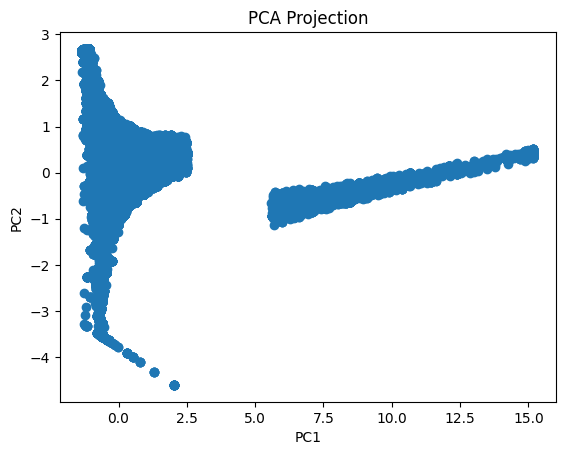

In [30]:
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

This plots the data in reduced 2D space to visualize patterns or potential cluster separation.

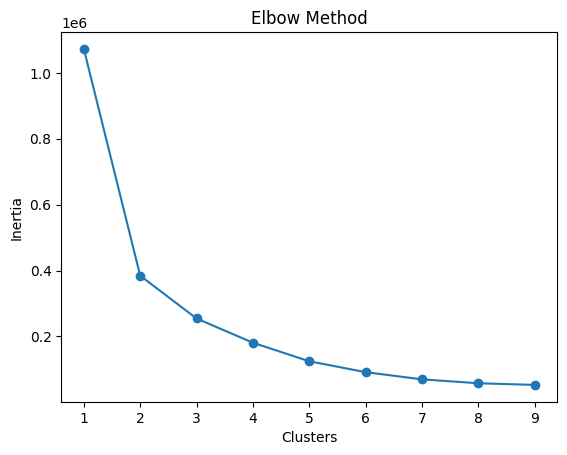

In [31]:
from sklearn.cluster import KMeans
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

uses the Elbow Method to find the optimal number of clusters by identifying where inertia starts decreasing slowly.

# Model Selection


**MiniBatchKMeans**: MiniBatchKMeans was used for its efficiency and scalability, as it can handle large datasets quickly while providing good clustering performance.

**Hierarchical Clustering**: Hierarchical Clustering was used to understand the structure and relationships between clusters, providing a clear hierarchical grouping of data points.

**Gaussian Mixture Model (GMM)**: Gaussian Mixture Model (GMM) was used to capture probabilistic and overlapping clusters, allowing more flexible cluster boundaries compared to KMeans.


# MiniBatchKMeans



In [32]:
from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(n_clusters=3, batch_size=1000, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df['Cluster'] = clusters

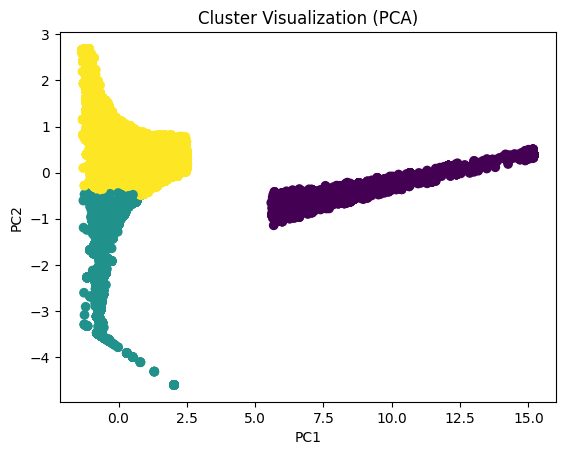

In [33]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Cluster Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [34]:
from sklearn.metrics import silhouette_score
final_score = silhouette_score(X_pca, clusters)
print("Final Silhouette Score:", final_score)

Final Silhouette Score: 0.46307287899769634


In [35]:
cluster_summary = df.groupby('Cluster')[[
    'Estimated PV System Size (kWdc)',
    'PV System Size (kWac)',
    'Estimated Annual PV Energy Production (kWh)',
    'Efficiency',
    'AC_DC_Ratio'
]].mean()

print("\nCluster Summary:")
print(cluster_summary)



Cluster Summary:
         Estimated PV System Size (kWdc)  PV System Size (kWac)  \
Cluster                                                           
0                             641.693655             476.557713   
1                               6.441802               5.502888   
2                               8.692241               7.430208   

         Estimated Annual PV Energy Production (kWh)   Efficiency  AC_DC_Ratio  
Cluster                                                                         
0                                      753245.519413  1173.837230     0.822716  
1                                        7557.530102  1173.078283     0.854158  
2                                       10204.497365  1174.053350     0.854867  


Cluster 0 → Large-Scale / Industrial Systems:This cluster represents large industrial or utility-scale solar projects with significantly higher capacity and energy output.

Cluster 1 → Small-Scale / Residential Systems: This cluster represents residential solar installations, designed for small energy needs like homes.

Cluster 2 → Medium-Scale / Commercial Systems: This cluster represents small commercial or advanced residential systems, slightly larger than typical home setups.

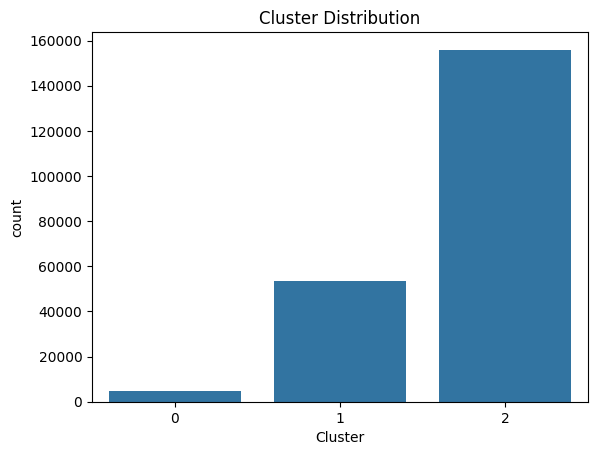

In [36]:
sns.countplot(x=df['Cluster'])
plt.title("Cluster Distribution")
plt.show()

shows the number of data points in each cluster, helping understand how the data is distributed across clusters.

# Hierarchical Clustering(Agglomerative)

In [37]:
from sklearn.cluster import AgglomerativeClustering
sample_size = 2000   # SAFE LIMIT
X_sample = X_pca[:sample_size]

hc = AgglomerativeClustering(n_clusters=3)
hc_clusters = hc.fit_predict(X_sample)

df_sample = df.iloc[:sample_size].copy()
df_sample['HC_Cluster'] = hc_clusters

print("Hierarchical Score:",
      silhouette_score(X_sample, hc_clusters))


Hierarchical Score: 0.4727673279971467


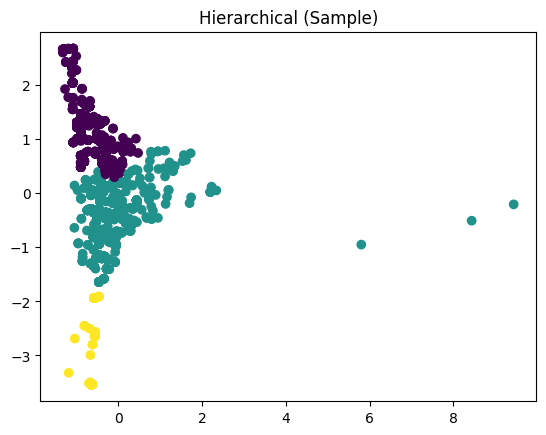

In [38]:
plt.scatter(X_sample[:,0], X_sample[:,1], c=hc_clusters)
plt.title("Hierarchical (Sample)")
plt.show()

In [39]:
hc_summary = df_sample.groupby('HC_Cluster')[[
    'Estimated PV System Size (kWdc)',
    'PV System Size (kWac)',
    'Estimated Annual PV Energy Production (kWh)',
    'Efficiency',
    'AC_DC_Ratio'
]].mean()

print("Hierarchical Cluster Summary:")
print(hc_summary)

Hierarchical Cluster Summary:
            Estimated PV System Size (kWdc)  PV System Size (kWac)  \
HC_Cluster                                                           
0                                  5.380447               4.601132   
1                                  7.929404               6.774023   
2                                  3.602473               3.075583   

            Estimated Annual PV Energy Production (kWh)   Efficiency  \
HC_Cluster                                                             
0                                           6319.151316  1174.622301   
1                                           9306.262278  1173.606971   
2                                           4224.017668  1172.334903   

            AC_DC_Ratio  
HC_Cluster               
0              0.855275  
1              0.854493  
2              0.853605  


Cluster 2 → Small-Scale / Residential Systems: This cluster represents small residential solar installations with minimal energy requirements.

Cluster 0 → Medium-Scale Systems: This cluster represents typical residential or small commercial systems, slightly larger than basic home setups.

Cluster 1 → Large-Scale / Advanced Systems: This cluster represents larger residential or small commercial installations with higher energy demand.

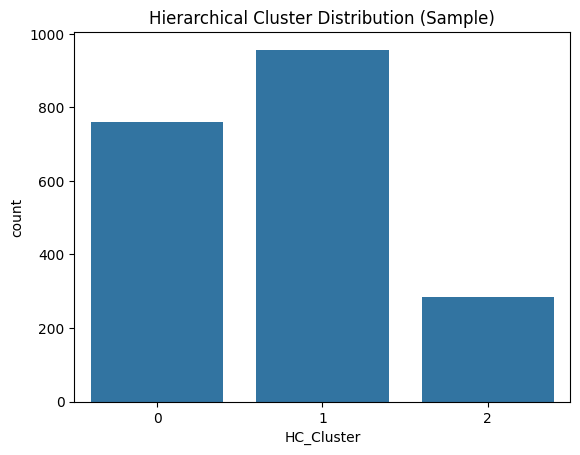

In [40]:
sns.countplot(x=df_sample['HC_Cluster'])
plt.title("Hierarchical Cluster Distribution (Sample)")
plt.show()

shows the number of data points in each cluster, helping understand how the data is distributed across clusters.

# Gaussian Mixture Model (GMM)

In [41]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_clusters = gmm.fit_predict(X_pca)

df['GMM_Cluster'] = gmm_clusters

print("GMM Score:", silhouette_score(X_pca, gmm_clusters))

GMM Score: 0.3057888851329125


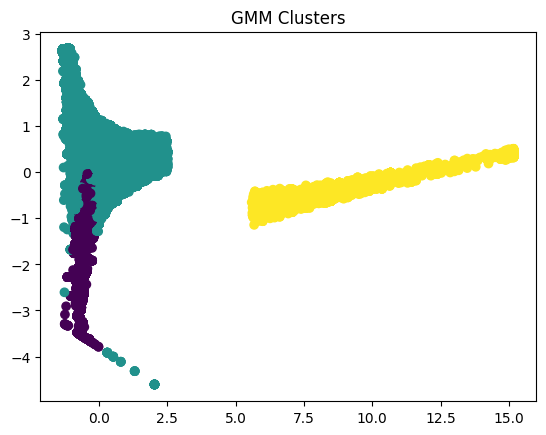

In [42]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=gmm_clusters)
plt.title("GMM Clusters")
plt.show()

In [43]:
gmm_summary = df.groupby('GMM_Cluster')[[
    'Estimated PV System Size (kWdc)',
    'PV System Size (kWac)',
    'Estimated Annual PV Energy Production (kWh)',
    'Efficiency',
    'AC_DC_Ratio'
]].mean()

print("GMM Cluster Summary:")
print(gmm_summary)

GMM Cluster Summary:
             Estimated PV System Size (kWdc)  PV System Size (kWac)  \
GMM_Cluster                                                           
0                                   5.752624               4.914786   
1                                   8.991985               7.686128   
2                                 641.693655             476.557713   

             Estimated Annual PV Energy Production (kWh)   Efficiency  \
GMM_Cluster                                                             
0                                            6749.780114  1173.229515   
1                                           10555.997169  1174.016727   
2                                          753245.519413  1173.837230   

             AC_DC_Ratio  
GMM_Cluster               
0               0.854274  
1               0.854838  
2               0.822716  


Cluster 0 → Small / Residential Systems: Represents typical residential solar installations with moderate energy needs.

Cluster 1 → Medium / Commercial Systems: Represents larger residential or small commercial systems with higher energy demand.

Cluster 2 → Large-Scale / Industrial Systems: Represents industrial or utility-scale solar projects, clearly separated from others.

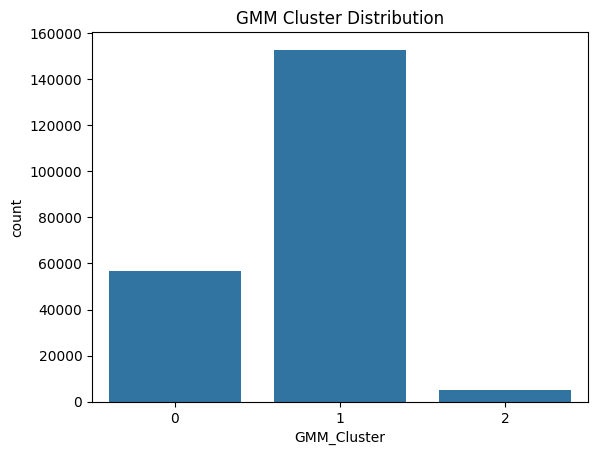

In [44]:
sns.countplot(x=df['GMM_Cluster'])
plt.title("GMM Cluster Distribution")
plt.show()

shows the number of data points in each cluster, helping understand how the data is distributed across clusters.

#Final comparision

In [45]:
print("KMeans:", silhouette_score(X_pca, df['Cluster']))
print("GMM:", silhouette_score(X_pca, df['GMM_Cluster']))
print("Hierarchical (sample):",
      silhouette_score(X_sample, hc_clusters))

KMeans: 0.46307287899769634
GMM: 0.3057888851329125
Hierarchical (sample): 0.4727673279971467


Hierarchical clustering achieved the highest silhouette score; however, it was applied only on a sampled dataset due to computational limitations. MiniBatchKMeans provided nearly comparable performance while being scalable to the full dataset, making it the most suitable model. GMM showed relatively lower performance, indicating less distinct cluster separation.

# Conclusion

The clustering analysis successfully segmented solar projects into residential, commercial, and industrial categories based on system size and energy production. The results highlight that while large-scale systems dominate energy output, smaller installations are more prevalent, indicating strong residential adoption. Although efficiency remains consistent across clusters, suggesting standardized technology, further validation using multiple clustering techniques and additional features such as geographic factors could enhance model robustness. These insights can support energy policy planning, infrastructure investment decisions, and targeted solar adoption strategies.
